In [54]:
from utils.orthanc_utils import *
from utils.db_utils import *
from utils.plot_utils import *
from utils.mri_sorter import MRI_Sorter
from utils.classifier_utils import *
import torch
import albumentations as A

DB_PATH = "image_clasp_db.json"
ORTHANC = "http://localhost:8042"
METRICS_PATH = 'clasp_metrics.csv'
AUTH = ("orthanc","orthanc")

SESSION = requests.Session()
SESSION.auth = AUTH
SESSION.trust_env = False
studies = fetch_db_studies()
study = studies[0]
mri_sorter = MRI_Sorter(study)

In [55]:

dicom_info_2D = mri_sorter.dicom_info.loc[mri_sorter.dicom_info['Dimension'] == 2]

sort_dict_2D = {}

for series_uid, series_df in dicom_info_2D.groupby('SeriesUID'):
    # Initialize the dictionary for each series
    sort_dict_2D[series_uid] = {
        'Description': series_df.iloc[0]['SeriesDescription'],
        'N': len(series_df),
        'Dimension': 2
    }

# Initialize lists to store results
series_df_list = []

# Process unique ImageOrientationPatients
for unique_or in dicom_info_2D['ImageOrientationPatient'].dropna().unique():
    # Filter and sort DataFrame
    unique_df = dicom_info_2D[dicom_info_2D['ImageOrientationPatient'] == unique_or]
    unique_df = unique_df.set_index(['PixelSpacing', 'SliceThickness']).sort_index()

    # Group by unique indices (PixelSpacing, SliceThickness)
    for unique_idx, series_df in unique_df.groupby(level=[0, 1]):
        # Group by image shape
        for unique_imshape, shape_group in series_df.groupby('ImageShape'):
            # Filter for series with more than one entry
            series_df_list.append(series_df)

stack_df_list = [df for df in series_df_list if df['SliceLocation'].nunique() > 1]
single_df_list = [df for df in series_df_list if df['SliceLocation'].nunique() == 1]

static_stack_list = [
            df
            for df in stack_df_list
            if df.loc[df['SliceLocation'] == df['SliceLocation'].unique()[0]]['InstanceNumber'].nunique() == 1
        ]

cine_stack_list = [
            df
            for df in stack_df_list
            if df.loc[df['SliceLocation'] == df['SliceLocation'].unique()[0]]['InstanceNumber'].nunique() > 1
        ]

cine_stack_list, ss_mh_list = mri_sorter.split_by_similar_triggertime(cine_stack_list)

static_single_list = [
            df
            for df in single_df_list
            if df.loc[df['SliceLocation'] == df['SliceLocation'].unique()[0]]['InstanceNumber'].nunique() == 1
        ]

cine_single_list = [
            df
            for df in single_df_list
            if df.loc[df['SliceLocation'] == df['SliceLocation'].unique()[0]]['InstanceNumber'].nunique() > 1 
        ]

In [57]:
[stack['SeriesDescription'].values[0] for stack in cine_stack_list]

['ML cine']

In [60]:
series_df = cine_stack_list[0]
mid_slice = series_df.SliceLocation.values[len(series_df.SliceLocation.values)//2]
mid_dia_id = series_df.loc[series_df['SliceLocation'] == mid_slice].iloc[0]['ID']

image = fetch_orthanc_dicom(mid_dia_id).pixel_array
with torch.no_grad():
    output = model(preprocess(image))
probs = torch.softmax(output, dim=1).squeeze()
label = label_dict[np.argmax(probs).item()]

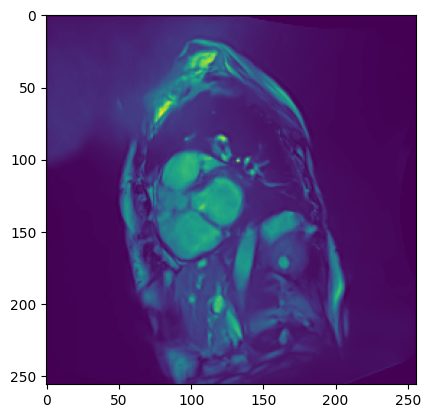

In [67]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.imshow(image)
plt.show()

In [62]:
series_df

SeriesUID  \
PixelSpacing SliceThickness                                                 
1.5625       10.0            12a8f30b-4de3076d-a755fa4a-cc9c5101-8d849878   
             10.0            12a8f30b-4de3076d-a755fa4a-cc9c5101-8d849878   
             10.0            12a8f30b-4de3076d-a755fa4a-cc9c5101-8d849878   
             10.0            12a8f30b-4de3076d-a755fa4a-cc9c5101-8d849878   
             10.0            12a8f30b-4de3076d-a755fa4a-cc9c5101-8d849878   
...                                                                   ...   
             10.0            ff433dbd-20a1527f-7723858b-1e2085cb-111ddf1f   
             10.0            ff433dbd-20a1527f-7723858b-1e2085cb-111ddf1f   
             10.0            ff433dbd-20a1527f-7723858b-1e2085cb-111ddf1f   
             10.0            ff433dbd-20a1527f-7723858b-1e2085cb-111ddf1f   
             10.0            ff433dbd-20a1527f-7723858b-1e2085cb-111ddf1f   

                            SeriesDescription  Dimension  N_timesteps  \
PixelSpacing SliceThickness                                             
1.5625       10.0                     ML cine          2           36   
             10.0                     ML cine          2           36   
             10.0                     ML cine          2           36   
             10.0                     ML cine          2           36   
             10.0                     ML cine          2           36   
...                                       ...        ...          ...   
             10.0                     ML cine          2           36   
             10.0                     ML cine          2           36   
             10.0                     ML cine          2           36   
             10.0                     ML cine          2           36   
             10.0                     ML cine          2           36   

                             ImageShape  venc     rr  \
PixelSpacing SliceThickness                            
1.5625       10.0            (256, 256)     0  930.0   
             10.0            (256, 256)     0  930.0   
             10.0            (256, 256)     0  930.0   
             10.0            (256, 256)     0  930.0   
             10.0            (256, 256)     0  930.0   
...                                 ...   ...    ...   
             10.0            (256, 256)     0  937.0   
             10.0            (256, 256)     0  937.0   
             10.0            (256, 256)     0  937.0   
             10.0            (256, 256)     0  937.0   
             10.0            (256, 256)     0  937.0   

                                                                       ID  \
PixelSpacing SliceThickness                                                 
1.5625       10.0            bbae3361-39d309e1-3246c79c-6c24d439-9752c32d   
             10.0            6fb4af50-d5b7e275-c8713c78-440408f9-2222a3dd   
             10.0            401f8b79-ff4ff061-d7a8462b-930dfac4-12219259   
             10.0            33201a23-701d0027-13620311-a65e99aa-97c2eedc   
             10.0            326354d7-b8b64812-04c80c3e-2c888894-dba0c067   
...                                                                   ...   
             10.0            7d73a6cd-29cdf7f5-af0b6cb7-7dfc027e-07c685e0   
             10.0            83de3f79-837f497d-25168055-bfcfb9a8-81760754   
             10.0            ab208da7-7ba574a7-2b3ca689-7d6e0df0-dbdd7db5   
             10.0            7f872848-a9fbe687-c70a4441-28e6e2e1-2cc1dc54   
             10.0            defdc6df-af55da24-4099ec13-3c0b1c19-1e44e9cf   

                                                       ImageOrientationPatient  \
PixelSpacing SliceThickness                                                      
1.5625       10.0            (0.38376819254222, 0.85606986455295, -0.346217...   
             10.0            (0.38376819254222, 0.85606986455295, -0.346217...   
             10.0            (0.38376819254222, 0.856

In [ ]:
%matplotlib inline
plt.imshow(np.squeeze(image))
plt.show()

In [ ]:
cine_stack_list[0]